# 🅿️ Parking Lot Detection — AIoT Mini-Project
### Module : Apprentissage Profond, Master 1, I2A Pro 2026
**Thème :** Sécurité & Smart City

| Livrable | Statut |
|---|---|
| Dataset public PKLot (Kaggle) | ✅ |
| Modèle CNN + Transfer Learning (Faster R-CNN + ResNet50) | ✅ |
| Courbes Loss par epoch | ✅ |
| Courbes Accuracy par epoch | ✅ |
| Matrice de confusion | ✅ |
| Précision / Rappel / F1-score | ✅ |
| Micro-service Flask | ✅ |
| Modèle sauvegardé `.pth` | ✅ |

## 1. Imports & Configuration

In [1]:
import os, json, cv2, random, warnings, base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {device}")

# ── Paths
ROOT      = "/kaggle/input/datasets/ammarnassanalhajali/pklot-dataset"
TRAIN_DIR = ROOT + "/train"
VAL_DIR   = ROOT + "/valid"
TEST_DIR  = ROOT + "/test"

# ── Hyper-parameters
NUM_EPOCHS   = 10
BATCH_SIZE   = 4
LR           = 0.005
MOMENTUM     = 0.9
WEIGHT_DECAY = 0.0005
CONF_THRESH  = 0.7
IOU_THRESH   = 0.5
NUM_CLASSES  = 3   # 0=background  1=space-empty  2=space-occupied

CAT_NAMES  = {1: "space-empty", 2: "space-occupied"}
CAT_COLORS = {1: (0, 200, 80),  2: (220, 50, 50)}

print("✅ Configuration done")

✅ Device : cuda
✅ Configuration done


## 2. Load COCO Annotations

In [2]:
def load_coco(path):
    with open(path) as f:
        return json.load(f)

train_data = load_coco(f"{TRAIN_DIR}/_annotations.coco.json")
val_data   = load_coco(f"{VAL_DIR}/_annotations.coco.json")
test_data  = load_coco(f"{TEST_DIR}/_annotations.coco.json")

print(f"Train : {len(train_data['images'])} images")
print(f"Val   : {len(val_data['images'])} images")
print(f"Test  : {len(test_data['images'])} images")
print(f"Categories : {train_data['categories']}")

Train : 8691 images
Val   : 2483 images
Test  : 1242 images
Categories : [{'id': 0, 'name': 'spaces', 'supercategory': 'none'}, {'id': 1, 'name': 'space-empty', 'supercategory': 'spaces'}, {'id': 2, 'name': 'space-occupied', 'supercategory': 'spaces'}]


## 3. Dataset Statistics

In [3]:
def analyze_dataset(data, name):
    cat_counts, bbox_sizes = defaultdict(int), []
    for ann in data['annotations']:
        cat_counts[ann['category_id']] += 1
        bbox_sizes.append(ann['area'])
    id2n = {c['id']: c['name'] for c in data['categories']}
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(f"Images: {len(data['images'])}  |  Annotations: {len(data['annotations'])}")
    for k, v in cat_counts.items():
        print(f"  {id2n[k]}: {v}")
    print(f"BBox area — mean:{np.mean(bbox_sizes):.0f}  min:{np.min(bbox_sizes):.0f}  max:{np.max(bbox_sizes):.0f}")
    return cat_counts, bbox_sizes

train_stats, train_bboxes = analyze_dataset(train_data, "TRAIN")
val_stats,   val_bboxes   = analyze_dataset(val_data,   "VALIDATION")
test_stats,  test_bboxes  = analyze_dataset(test_data,  "TEST")


TRAIN
Images: 8691  |  Annotations: 497856
  space-occupied: 231948
  space-empty: 265908
BBox area — mean:1903  min:544  max:10666

VALIDATION
Images: 2483  |  Annotations: 143316
  space-occupied: 69687
  space-empty: 73629
BBox area — mean:1890  min:544  max:10666

TEST
Images: 1242  |  Annotations: 70684
  space-empty: 36584
  space-occupied: 34100
BBox area — mean:1919  min:544  max:10666


## 4. Visualize Sample Annotations

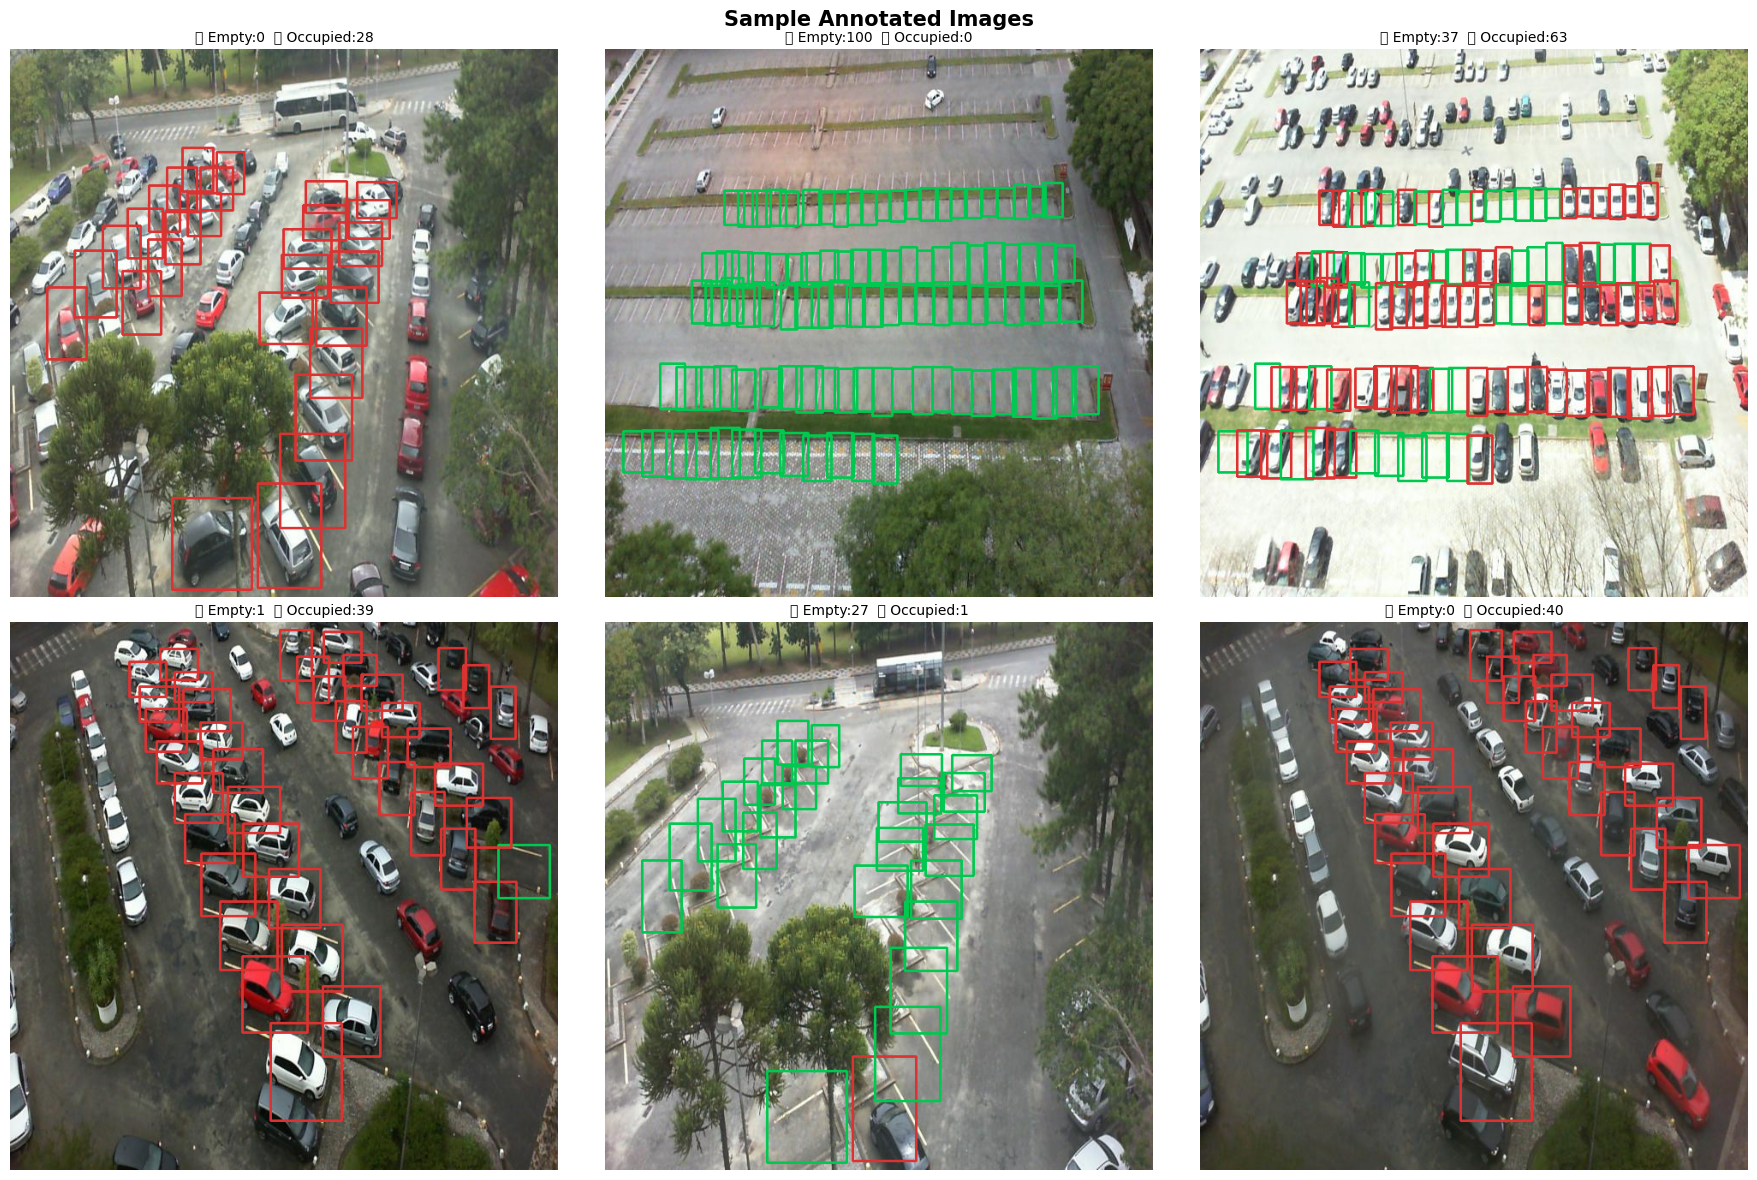

✅ Saved → sample_annotations.png


In [4]:
def visualize_annotations(data, img_dir, n=6, save='sample_annotations.png'):
    id2n     = {c['id']: c['name'] for c in data['categories']}
    img2anns = defaultdict(list)
    for ann in data['annotations']:
        img2anns[ann['image_id']].append(ann)
    samples = random.sample(data['images'], min(n, len(data['images'])))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Sample Annotated Images', fontsize=15, fontweight='bold')
    for ax, info in zip(axes.ravel(), samples):
        img = cv2.cvtColor(cv2.imread(f"{img_dir}/{info['file_name']}"), cv2.COLOR_BGR2RGB)
        emp = occ = 0
        for ann in img2anns[info['id']]:
            x, y, w, h = map(int, ann['bbox'])
            c = CAT_COLORS.get(ann['category_id'], (200,200,200))
            cv2.rectangle(img, (x,y), (x+w,y+h), c, 2)
            if ann['category_id'] == 1: emp += 1
            else: occ += 1
        ax.imshow(img)
        ax.set_title(f"🟢 Empty:{emp}  🔴 Occupied:{occ}", fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {save}")

visualize_annotations(train_data, TRAIN_DIR)

## 5. Class Distribution Chart

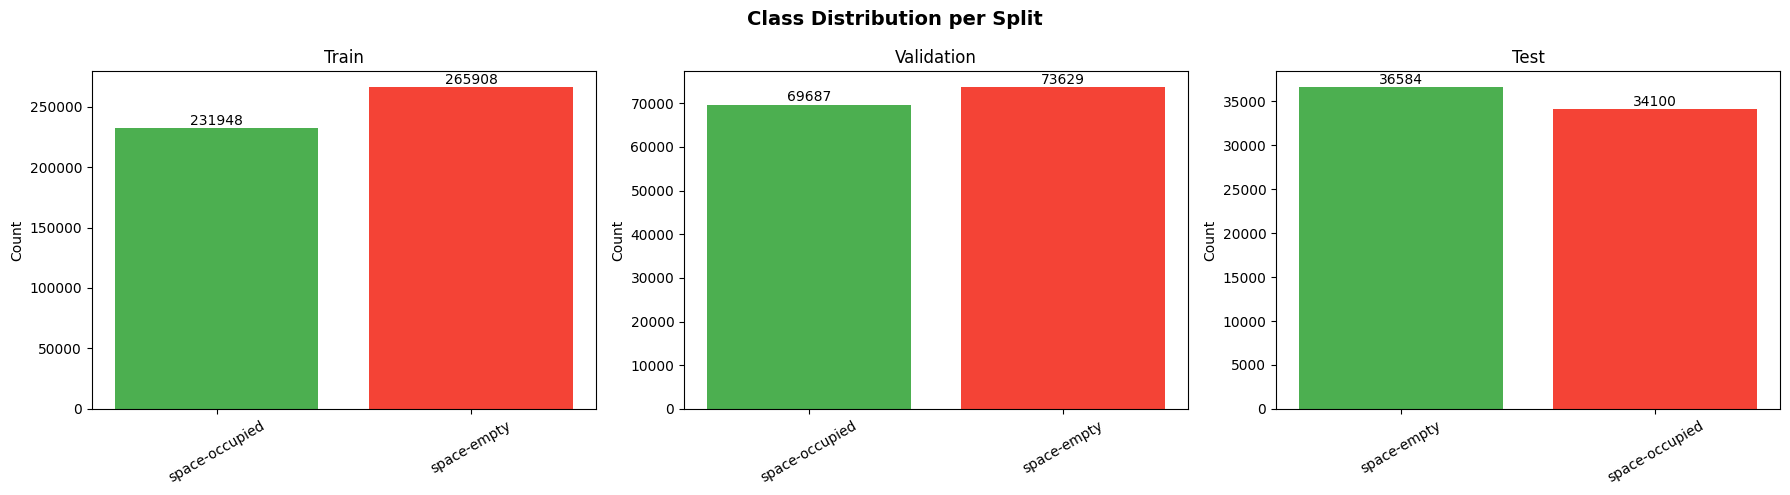

✅ Saved → category_distribution.png


In [5]:
def plot_distribution(save='category_distribution.png'):
    id2n = {c['id']: c['name'] for c in train_data['categories']}
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Class Distribution per Split', fontsize=14, fontweight='bold')
    for ax, (name, stats) in zip(axes, [('Train', train_stats),
                                         ('Validation', val_stats),
                                         ('Test', test_stats)]):
        cats   = [id2n.get(k, str(k)) for k in stats]
        counts = list(stats.values())
        bars   = ax.bar(cats, counts, color=['#4CAF50','#F44336'])
        ax.set_title(name); ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=30)
        for b, v in zip(bars, counts):
            ax.text(b.get_x()+b.get_width()/2, v+max(counts)*0.01,
                    str(v), ha='center', fontsize=10)
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {save}")

plot_distribution()

## 6. PyTorch Dataset & DataLoaders

In [6]:
class ParkingLotDataset(Dataset):
    def __init__(self, coco_data, img_dir):
        self.img_dir  = img_dir
        self.img2anns = defaultdict(list)
        for ann in coco_data['annotations']:
            self.img2anns[ann['image_id']].append(ann)
        self.images = [img for img in coco_data['images'] if self.img2anns[img['id']]]
        print(f"  ✔ {len(self.images)} valid images")

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        info = self.images[idx]
        img  = cv2.cvtColor(cv2.imread(f"{self.img_dir}/{info['file_name']}"),
                            cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        boxes, labels, areas = [], [], []
        for ann in self.img2anns[info['id']]:
            x, y, w, h = ann['bbox']
            if w <= 0 or h <= 0: continue
            x1, y1 = max(0,x), max(0,y)
            x2, y2 = min(x+w, info['width']), min(y+h, info['height'])
            if x2 <= x1 or y2 <= y1: continue
            boxes.append([x1,y1,x2,y2]); labels.append(ann['category_id'])
            areas.append((x2-x1)*(y2-y1))
        if not boxes:
            boxes, labels, areas = [[0,0,1,1]], [1], [1]
        target = {
            'boxes':    torch.as_tensor(boxes,  dtype=torch.float32),
            'labels':   torch.as_tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([info['id']]),
            'area':     torch.as_tensor(areas,  dtype=torch.float32),
            'iscrowd':  torch.zeros(len(boxes), dtype=torch.int64),
        }
        return torch.from_numpy(img).permute(2,0,1), target

def collate_fn(b): return tuple(zip(*b))

print("Building datasets...")
train_ds = ParkingLotDataset(train_data, TRAIN_DIR)
val_ds   = ParkingLotDataset(val_data,   VAL_DIR)
test_ds  = ParkingLotDataset(test_data,  TEST_DIR)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  1,          shuffle=False, num_workers=2, collate_fn=collate_fn)

print(f"Batches — Train:{len(train_loader)}  Val:{len(val_loader)}  Test:{len(test_loader)}")

Building datasets...
  ✔ 8502 valid images
  ✔ 2424 valid images
  ✔ 1216 valid images
Batches — Train:2126  Val:606  Test:1216


## 7. Model — Faster R-CNN + ResNet50 FPN (Transfer Learning)

In [7]:
def get_model(num_classes):
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    in_f  = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, num_classes)
    return model

model = get_model(NUM_CLASSES).to(device)
print(f"✅ Faster R-CNN + ResNet50 FPN loaded")
print(f"   Classes: 0=background  1=space-empty  2=space-occupied")

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Trainable params: {total_params:,}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 190MB/s]


✅ Faster R-CNN + ResNet50 FPN loaded
   Classes: 0=background  1=space-empty  2=space-occupied
   Trainable params: 41,081,886


## 8. Helper Functions (IoU & Accuracy)

In [8]:
def compute_iou(b1, b2):
    x1, y1 = max(b1[0],b2[0]), max(b1[1],b2[1])
    x2, y2 = min(b1[2],b2[2]), min(b1[3],b2[3])
    inter  = max(0, x2-x1) * max(0, y2-y1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-6)

@torch.no_grad()
def compute_accuracy(model, loader, device, conf=CONF_THRESH, iou=IOU_THRESH):
    """Detection accuracy = correctly matched boxes / total GT boxes"""
    model.eval()
    correct, total = 0, 0
    for imgs, targets in loader:
        imgs  = [img.to(device) for img in imgs]
        preds = model(imgs)
        for pred, tgt in zip(preds, targets):
            gt_b = tgt['boxes'].numpy()
            gt_l = tgt['labels'].numpy()
            keep = pred['scores'] > conf
            pb   = pred['boxes'][keep].cpu().numpy()
            pl   = pred['labels'][keep].cpu().numpy()
            total += len(gt_l)
            matched = set()
            for pbox, plbl in zip(pb, pl):
                for gi, (gbox, glbl) in enumerate(zip(gt_b, gt_l)):
                    if gi in matched: continue
                    if compute_iou(pbox, gbox) >= iou and plbl == glbl:
                        correct += 1; matched.add(gi); break
    return correct / max(total, 1)

print("✅ Helper functions ready")

✅ Helper functions ready


## 9. Training Loop

In [9]:
def train_one_epoch(model, optimizer, loader, device, epoch):
    model.train()
    total, n = 0, 0
    for imgs, tgts in tqdm(loader, desc=f"  Train epoch {epoch}"):
        imgs = [img.to(device) for img in imgs]
        tgts = [{k: v.to(device) if isinstance(v, torch.Tensor) else v
                 for k,v in t.items()} for t in tgts]
        try:
            loss = sum(model(imgs, tgts).values())
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item(); n += 1
        except Exception as e:
            print(f"    ⚠ {e}"); continue
    return total / max(n, 1)

@torch.no_grad()
def evaluate_loss(model, loader, device):
    model.train()
    total, n = 0, 0
    for imgs, tgts in tqdm(loader, desc="  Val loss  "):
        imgs = [img.to(device) for img in imgs]
        tgts = [{k: v.to(device) if isinstance(v, torch.Tensor) else v
                 for k,v in t.items()} for t in tgts]
        try:
            loss = sum(model(imgs, tgts).values())
            total += loss.item(); n += 1
        except: continue
    return total / max(n, 1)

print("✅ Training functions ready")

✅ Training functions ready


## 10. Run Training (Loss + Accuracy per Epoch)

In [10]:
params    = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

print("🚀 Training started\n" + "─"*60)
for epoch in range(1, NUM_EPOCHS + 1):
    tl = train_one_epoch(model, optimizer, train_loader, device, epoch)
    vl = evaluate_loss(model, val_loader, device)
    scheduler.step()

    ta = compute_accuracy(model, train_loader, device)
    va = compute_accuracy(model, val_loader,   device)

    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Loss → train:{tl:.4f} val:{vl:.4f} | "
          f"Acc  → train:{ta*100:.1f}% val:{va*100:.1f}% | "
          f"LR:{optimizer.param_groups[0]['lr']:.6f}")

torch.save(model.state_dict(), 'parking_lot_detector.pth')
print("\n✅ Model saved → parking_lot_detector.pth")

🚀 Training started
────────────────────────────────────────────────────────────


  Val loss  : 100%|██████████| 606/606 [04:21<00:00,  2.32it/s]


Epoch 01/10 | Loss → train:0.2200 val:0.1244 | Acc  → train:71.9% val:70.7% | LR:0.005000


  Val loss  : 100%|██████████| 606/606 [04:21<00:00,  2.32it/s]


Epoch 02/10 | Loss → train:0.0740 val:0.0587 | Acc  → train:97.0% val:97.5% | LR:0.005000


...

Epoch 08/10 | Loss → train:0.0268 val:0.0281 | Acc  → train:97.6% val:97.7% | LR:0.000050


  Val loss  : 100%|██████████| 606/606 [04:22<00:00,  2.31it/s]


Epoch 09/10 | Loss → train:0.0268 val:0.0278 | Acc  → train:97.8% val:97.9% | LR:0.000005


  Val loss  : 100%|██████████| 606/606 [04:21<00:00,  2.31it/s]


Epoch 10/10 | Loss → train:0.0263 val:0.0277 | Acc  → train:97.7% val:97.8% | LR:0.000005

✅ Model saved → parking_lot_detector.pth


## 11. Courbes de Loss

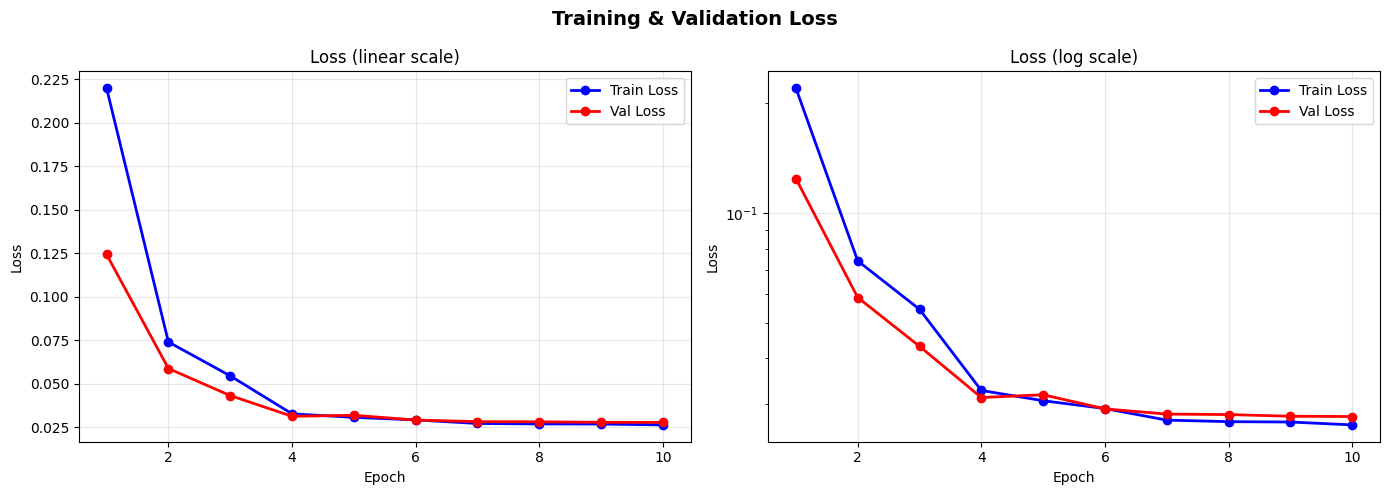

✅ Saved → loss_curves.png


In [11]:
def plot_loss_curves(history, save='loss_curves.png'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training & Validation Loss', fontsize=14, fontweight='bold')
    for ax, scale in [(ax1,'linear'), (ax2,'log')]:
        ax.plot(epochs, history['train_loss'], 'b-o', label='Train Loss', lw=2)
        ax.plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   lw=2)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.set_yscale(scale); ax.set_title(f'Loss ({scale} scale)')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {save}")

plot_loss_curves(history)

## 12. Courbes d'Accuracy (par Epoch)

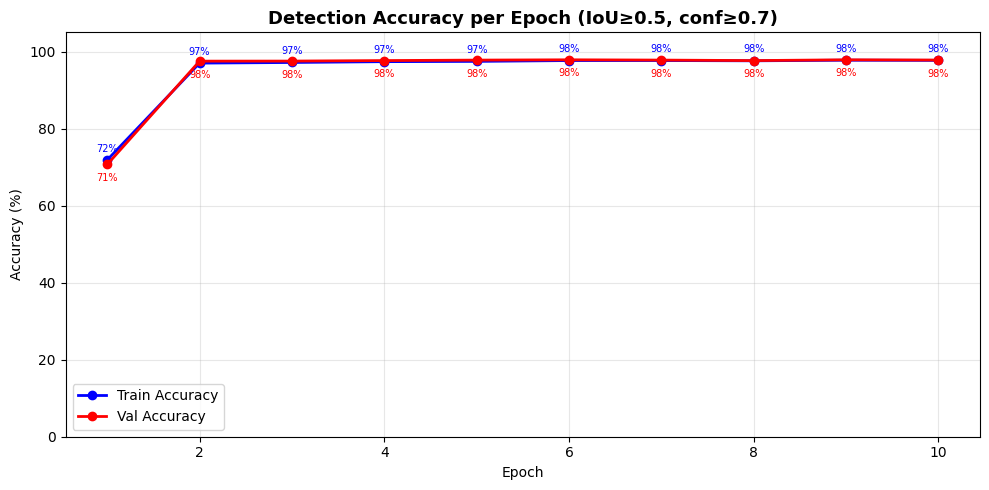

✅ Saved → accuracy_curves.png


In [12]:
def plot_accuracy_curves(history, save='accuracy_curves.png'):
    epochs = range(1, len(history['train_acc']) + 1)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, [v*100 for v in history['train_acc']], 'b-o', label='Train Accuracy', lw=2)
    ax.plot(epochs, [v*100 for v in history['val_acc']],   'r-o', label='Val Accuracy',   lw=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.set_title('Detection Accuracy per Epoch (IoU≥0.5, conf≥0.7)',
                 fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 105)
    for ep, ta, va in zip(epochs, history['train_acc'], history['val_acc']):
        ax.annotate(f"{ta*100:.0f}%", (ep, ta*100), textcoords="offset points",
                    xytext=(0, 6),  fontsize=7, color='blue', ha='center')
        ax.annotate(f"{va*100:.0f}%", (ep, va*100), textcoords="offset points",
                    xytext=(0,-12), fontsize=7, color='red',  ha='center')
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {save}")

plot_accuracy_curves(history)

## 13. Matrice de Confusion

Building confusion matrix: 100%|██████████| 2424/2424 [04:19<00:00,  9.33it/s]


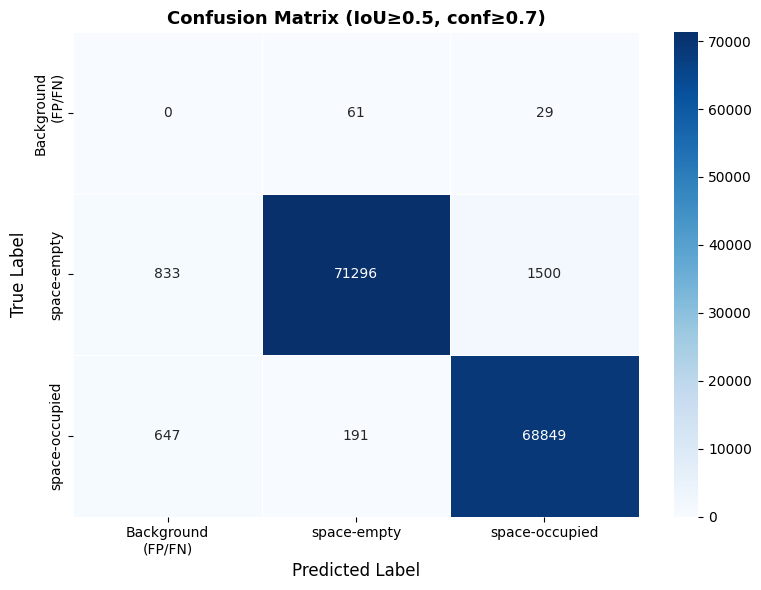

✅ Saved → confusion_matrix.png


In [13]:
def build_confusion_matrix(model, dataset, device, save='confusion_matrix.png'):
    model.eval()
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
    with torch.no_grad():
        for img_t, tgt in tqdm(DataLoader(dataset, 1, collate_fn=collate_fn),
                                desc="Building confusion matrix"):
            img_t  = img_t[0].to(device)
            gt_b   = tgt[0]['boxes'].numpy()
            gt_l   = tgt[0]['labels'].numpy()
            pred   = model([img_t])[0]
            keep   = pred['scores'] > CONF_THRESH
            pb     = pred['boxes'][keep].cpu().numpy()
            pl     = pred['labels'][keep].cpu().numpy()
            matched_gt = set()
            for pbox, plbl in zip(pb, pl):
                best_iou, best_gi = 0, -1
                for gi, (gbox, glbl) in enumerate(zip(gt_b, gt_l)):
                    if gi in matched_gt: continue
                    iou = compute_iou(pbox, gbox)
                    if iou > best_iou: best_iou, best_gi = iou, gi
                if best_iou >= IOU_THRESH and best_gi != -1:
                    cm[gt_l[best_gi], plbl] += 1
                    matched_gt.add(best_gi)
                else:
                    cm[0, min(plbl, NUM_CLASSES-1)] += 1
            for gi in range(len(gt_l)):
                if gi not in matched_gt:
                    cm[gt_l[gi], 0] += 1

    labels = ['Background\n(FP/FN)', 'space-empty', 'space-occupied']
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, linewidths=.5, ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label',      fontsize=12)
    ax.set_title('Confusion Matrix (IoU≥0.5, conf≥0.7)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {save}")
    return cm

cm = build_confusion_matrix(model, val_ds, device)

## 14. Précision / Rappel / F1-Score


📊 Per-class metrics:
  Background              P:0.000  R:0.000  F1:0.000
  space-empty             P:0.996  R:0.968  F1:0.982
  space-occupied          P:0.978  R:0.988  F1:0.983

  Macro Average           P:0.987  R:0.978  F1:0.983


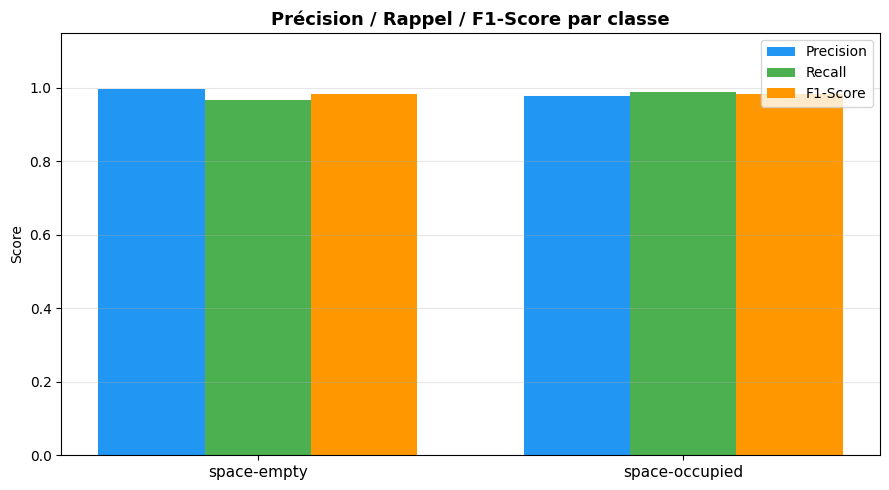

✅ Saved → precision_recall_f1.png


In [14]:
def compute_prf1(cm, save='precision_recall_f1.png'):
    cls_names = ['Background', 'space-empty', 'space-occupied']
    results   = {}
    print("\n📊 Per-class metrics:")
    for i, name in enumerate(cls_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        p  = tp / (tp + fp + 1e-6)
        r  = tp / (tp + fn + 1e-6)
        f1 = 2*p*r / (p + r + 1e-6)
        results[name] = {'Precision': p, 'Recall': r, 'F1': f1}
        print(f"  {name:22s}  P:{p:.3f}  R:{r:.3f}  F1:{f1:.3f}")
    target_cls = cls_names[1:]
    mp  = np.mean([results[k]['Precision'] for k in target_cls])
    mr  = np.mean([results[k]['Recall']    for k in target_cls])
    mf1 = np.mean([results[k]['F1']        for k in target_cls])
    print(f"\n  {'Macro Average':22s}  P:{mp:.3f}  R:{mr:.3f}  F1:{mf1:.3f}")

    df = pd.DataFrame({k: results[k] for k in target_cls}).T
    x  = np.arange(len(df)); w = 0.25
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x-w, df['Precision'], w, label='Precision', color='#2196F3')
    ax.bar(x,   df['Recall'],   w, label='Recall',    color='#4CAF50')
    ax.bar(x+w, df['F1'],       w, label='F1-Score',  color='#FF9800')
    ax.set_xticks(x); ax.set_xticklabels(df.index, fontsize=11)
    ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
    ax.set_title('Précision / Rappel / F1-Score par classe',
                 fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {save}")
    return results

metrics = compute_prf1(cm)

## 15. Visualisation des Prédictions

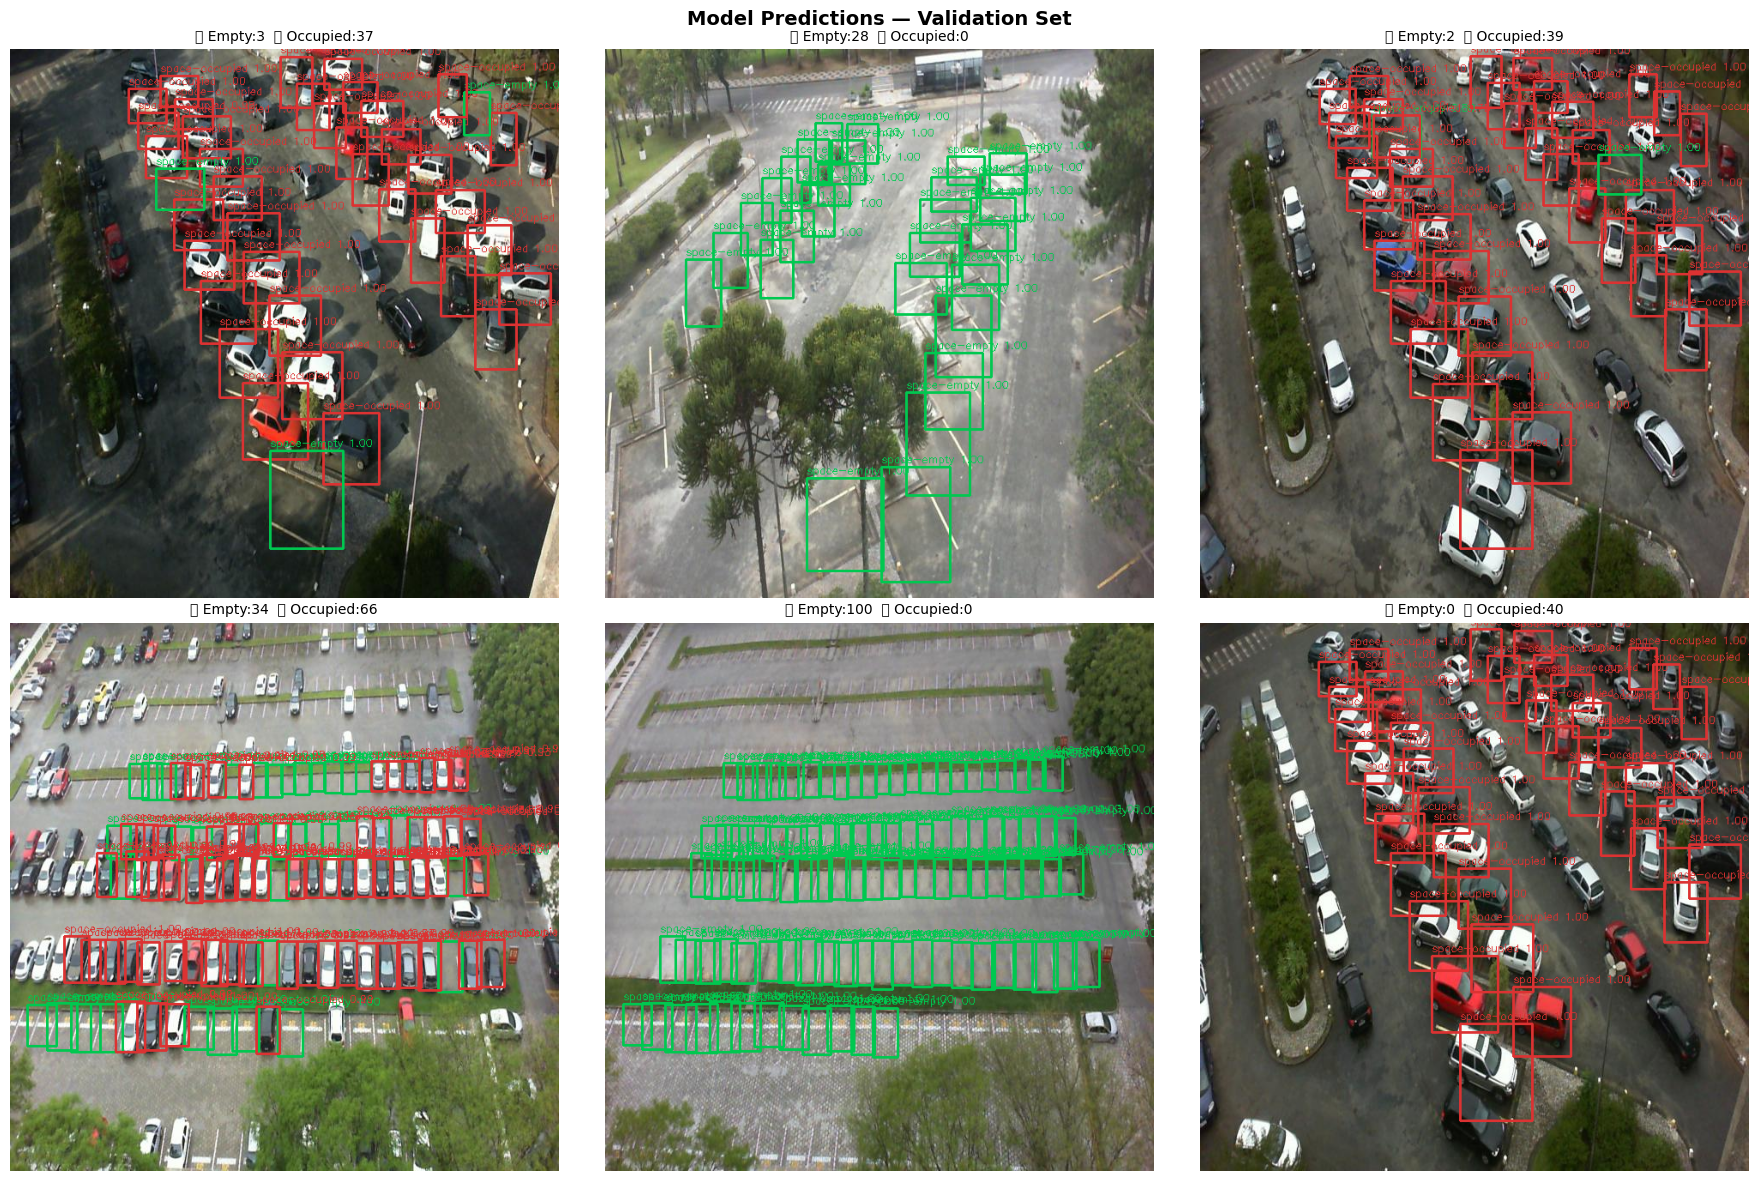

✅ Saved → predictions.png


In [15]:
@torch.no_grad()
def detect(model, img_np, device, thresh=CONF_THRESH):
    model.eval()
    t = torch.from_numpy(img_np).permute(2,0,1).unsqueeze(0).to(device)
    p = model(t)[0]
    k = p['scores'] > thresh
    return (p['boxes'][k].cpu().numpy(),
            p['labels'][k].cpu().numpy(),
            p['scores'][k].cpu().numpy())

def visualize_predictions(model, data, img_dir, device, n=6, save='predictions.png'):
    idxs = random.sample(range(len(data['images'])), n)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Model Predictions — Validation Set', fontsize=14, fontweight='bold')
    for ax, idx in zip(axes.ravel(), idxs):
        info   = data['images'][idx]
        img_np = cv2.cvtColor(cv2.imread(f"{img_dir}/{info['file_name']}"),
                              cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        boxes, labels, scores = detect(model, img_np, device)
        disp = (img_np * 255).astype(np.uint8).copy()
        emp = occ = 0
        for box, lbl, sc in zip(boxes, labels, scores):
            x1,y1,x2,y2 = map(int, box)
            c = CAT_COLORS.get(lbl, (200,200,200))
            cv2.rectangle(disp, (x1,y1), (x2,y2), c, 2)
            cv2.putText(disp, f"{CAT_NAMES.get(lbl,'?')} {sc:.2f}",
                        (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, c, 1)
            if lbl == 1: emp += 1
            else: occ += 1
        ax.imshow(disp)
        ax.set_title(f"🟢 Empty:{emp}  🔴 Occupied:{occ}", fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved → {save}")

visualize_predictions(model, val_data, VAL_DIR, device)

## 16. Test Set — Résultats CSV

In [16]:
def process_test_set(model, loader, device, save='test_results/test_results.csv'):
    os.makedirs(os.path.dirname(save), exist_ok=True)
    model.eval(); rows = []
    with torch.no_grad():
        for idx, (imgs, tgts) in enumerate(tqdm(loader, desc="Test set")):
            info   = test_data['images'][idx]
            img_np = cv2.cvtColor(cv2.imread(f"{TEST_DIR}/{info['file_name']}"),
                                  cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            boxes, labels, _ = detect(model, img_np, device)
            rows.append({
                'image_id':      info['id'],
                'file_name':     info['file_name'],
                'total_spots':   len(boxes),
                'empty_spots':   int(np.sum(labels == 1)),
                'occupied_spots':int(np.sum(labels == 2))
            })
    df = pd.DataFrame(rows)
    df.to_csv(save, index=False)
    print(f"✅ Saved → {save}")
    print(df[['total_spots','empty_spots','occupied_spots']].describe())
    return df

test_results = process_test_set(model, test_loader, device)

Test set: 100%|██████████| 1216/1216 [02:07<00:00,  9.56it/s]


✅ Saved → test_results/test_results.csv
       total_spots  empty_spots  occupied_spots
count  1216.000000  1216.000000     1216.000000
mean     56.959704    29.282072       27.677632
std      31.096677    30.507858       27.094373
min      28.000000     0.000000        0.000000
25%      28.000000     3.000000        2.000000
50%      40.000000    26.000000       26.000000
75%     100.000000    40.000000       40.000000
max     100.000000   100.000000       99.000000


## 17. Micro-service Flask

Cette cellule génère le fichier `app.py` — micro-service indépendant qui expose le modèle via une API REST.

In [17]:
FLASK_APP = '''
from flask import Flask, request, jsonify
from flask_cors import CORS
import torch, cv2, numpy as np, base64
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

app = Flask(__name__)
CORS(app)

MODEL_PATH  = "parking_lot_detector.pth"
NUM_CLASSES = 3
CONF_THRESH = 0.7
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CAT_NAMES   = {1: "space-empty", 2: "space-occupied"}

def load_model():
    m = fasterrcnn_resnet50_fpn(pretrained=False)
    in_f = m.roi_heads.box_predictor.cls_score.in_features
    m.roi_heads.box_predictor = FastRCNNPredictor(in_f, NUM_CLASSES)
    m.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    m.to(DEVICE).eval()
    return m

model = load_model()
print(f"Model loaded on {DEVICE}")

@torch.no_grad()
def predict(img_np):
    img_t = torch.from_numpy(img_np.astype(np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(DEVICE)
    pred  = model(img_t)[0]
    keep  = pred["scores"] > CONF_THRESH
    return (pred["boxes"][keep].cpu().numpy().tolist(),
            pred["labels"][keep].cpu().numpy().tolist(),
            pred["scores"][keep].cpu().numpy().tolist())

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok"})

@app.route("/predict", methods=["POST"])
def predict_route():
    try:
        data = request.get_json()
        if not data or "image" not in data:
            return jsonify({"error": "Missing image (base64)"}), 400
        img_bytes = base64.b64decode(data["image"])
        nparr     = np.frombuffer(img_bytes, np.uint8)
        img_rgb   = cv2.cvtColor(cv2.imdecode(nparr, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        boxes, labels, scores = predict(img_rgb)
        return jsonify({
            "empty":      sum(1 for l in labels if l == 1),
            "occupied":   sum(1 for l in labels if l == 2),
            "total":      len(boxes),
            "detections": [{"box": b, "label": CAT_NAMES.get(l,"?"), "score": round(s,4)}
                           for b,l,s in zip(boxes, labels, scores)]
        })
    except Exception as e:
        return jsonify({"error": str(e)}), 500

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False)
'''

with open('app.py', 'w') as f:
    f.write(FLASK_APP)

with open('requirements.txt', 'w') as f:
    f.write("flask\nflask-cors\ntorch\ntorchvision\nopencv-python-headless\nnumpy\n")

print("✅ app.py saved — Flask micro-service")
print("✅ requirements.txt saved")
print("\nUsage:")
print("  pip install -r requirements.txt")
print("  python app.py")
print("\nEndpoints:")
print("  GET  /health")
print("  POST /predict  {image: <base64>}")

✅ app.py saved — Flask micro-service
✅ requirements.txt saved

Usage:
  pip install -r requirements.txt
  python app.py

Endpoints:
  GET  /health
  POST /predict  {image: <base64>}


## 18. Résumé Final

In [18]:
print("\n" + "═"*60)
print("        MINI-PROJECT — RÉSUMÉ FINAL")
print("═"*60)
print(f"  Modèle         : Faster R-CNN + ResNet50 FPN")
print(f"  Dataset        : PKLot (Smart City Parking)")
print(f"  Epochs         : {NUM_EPOCHS}")
print(f"  Best Val Loss  : {min(history['val_loss']):.4f}")
print(f"  Best Val Acc   : {max(history['val_acc'])*100:.1f}%")
print(f"\n  Métriques par classe (val):")
for cls, m in metrics.items():
    if cls == 'Background': continue
    print(f"    {cls:22s}  P:{m['Precision']:.3f}  R:{m['Recall']:.3f}  F1:{m['F1']:.3f}")
print(f"\n  Fichiers générés :")
for f in ["parking_lot_detector.pth  ← modèle",
          "loss_curves.png           ← courbes Loss",
          "accuracy_curves.png       ← courbes Accuracy/epoch",
          "confusion_matrix.png      ← matrice de confusion",
          "precision_recall_f1.png   ← P/R/F1",
          "predictions.png           ← prédictions visuelles",
          "test_results/test_results.csv",
          "app.py                    ← micro-service Flask"]:
    print(f"    {f}")
print("═"*60)


════════════════════════════════════════════════════════════
        MINI-PROJECT — RÉSUMÉ FINAL
════════════════════════════════════════════════════════════
  Modèle         : Faster R-CNN + ResNet50 FPN
  Dataset        : PKLot (Smart City Parking)
  Epochs         : 10
  Best Val Loss  : 0.0277
  Best Val Acc   : 97.9%

  Métriques par classe (val):
    space-empty             P:0.996  R:0.968  F1:0.982
    space-occupied          P:0.978  R:0.988  F1:0.983

  Fichiers générés :
    parking_lot_detector.pth  ← modèle
    loss_curves.png           ← courbes Loss
    accuracy_curves.png       ← courbes Accuracy/epoch
    confusion_matrix.png      ← matrice de confusion
    precision_recall_f1.png   ← P/R/F1
    predictions.png           ← prédictions visuelles
    test_results/test_results.csv
    app.py                    ← micro-service Flask
════════════════════════════════════════════════════════════
